# CSIRO Image2Biomass: CNN + Transfer Learning Models

Predict five biomass quantities (`Dry_Green_g`, `Dry_Dead_g`, `Dry_Clover_g`,
`GDM_g`, `Dry_Total_g`) from pasture photographs plus two scalar tabular
features: `Pre_GSHH_NDVI` and `Height_Ave_cm`.

For evaluation, the Kaggle competition specifies globally weighted R² with weights 0.1 / 0.1 / 0.1 / 0.2 / 0.5.

As the title indicates, this notebook covers the implementation and results of our CNN model trained from scratch for this task and our transfer learning model that is fine-tuned from a ResNet 18.


## 0. Install / import packages

Also initializes the GPU device and sets the seed

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

torch.manual_seed(2025)
np.random.seed(2025)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


## 1. Download the data to this notebook

Refer to SETUP.md. From Kaggle, there is a zip file containing all the data used from this competition. Import the zip file to Google Drive.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

ZIP_PATH = Path("/content/drive/MyDrive/csiro-biomass.zip")
DATA_DIR = Path("/content/csiro-biomass")

!mkdir -p /content/csiro-biomass
!unzip -q -o "/content/drive/MyDrive/csiro-biomass.zip" -d "/content/csiro-biomass"

!find /content/csiro-biomass -maxdepth 2 -type f | head -20


Mounted at /content/drive
/content/csiro-biomass/sample_submission.csv
/content/csiro-biomass/train.csv
/content/csiro-biomass/test.csv
/content/csiro-biomass/train/ID1692894460.jpg
/content/csiro-biomass/train/ID560946727.jpg
/content/csiro-biomass/train/ID363069566.jpg
/content/csiro-biomass/train/ID342818398.jpg
/content/csiro-biomass/train/ID1831254380.jpg
/content/csiro-biomass/train/ID1028611175.jpg
/content/csiro-biomass/train/ID1385921939.jpg
/content/csiro-biomass/train/ID1874904894.jpg
/content/csiro-biomass/train/ID668475812.jpg
/content/csiro-biomass/train/ID1962197151.jpg
/content/csiro-biomass/train/ID576621307.jpg
/content/csiro-biomass/train/ID638711343.jpg
/content/csiro-biomass/train/ID196516535.jpg
/content/csiro-biomass/train/ID317990700.jpg
/content/csiro-biomass/train/ID2096636211.jpg
/content/csiro-biomass/train/ID94564238.jpg
/content/csiro-biomass/train/ID956512130.jpg


## 2. Inspect the data

`train.csv` is in long format, such that one row per (image, target_name) pair, so each image appears 5 times. To make future data splitting easier, we decided it would be useful to pivot this to wide format such that each image appears only once (this prevents the same image appearing in the train and eval, train and test, etc).


In [3]:
train_long = pd.read_csv(DATA_DIR / "train.csv")
test_long  = pd.read_csv(DATA_DIR / "test.csv")
sample_sub = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("train.csv:", train_long.shape, "columns:", train_long.columns.tolist())
print("test.csv :", test_long.shape,  "columns:", test_long.columns.tolist())
print("sample_submission:", sample_sub.shape, "columns:", sample_sub.columns.tolist())
print()
print("unique train images:", train_long["image_path"].nunique())
print("unique test images :", test_long["image_path"].nunique())
print("target_name values :", sorted(train_long["target_name"].unique()))
train_long.head()


train.csv: (1785, 9) columns: ['sample_id', 'image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm', 'target_name', 'target']
test.csv : (5, 3) columns: ['sample_id', 'image_path', 'target_name']
sample_submission: (5, 2) columns: ['sample_id', 'target']

unique train images: 357
unique test images : 1
target_name values : ['Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g', 'GDM_g']


,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750


## 3. Pivot long → wide and split by image

In [4]:
TARGETS = ["Dry_Green_g", "Dry_Dead_g", "Dry_Clover_g", "GDM_g", "Dry_Total_g"]
TARGET_WEIGHTS = {"Dry_Green_g": 0.1, "Dry_Dead_g": 0.1, "Dry_Clover_g": 0.1,
                  "GDM_g": 0.2, "Dry_Total_g": 0.5}
TABULAR_FEATURES = ["Pre_GSHH_NDVI", "Height_Ave_cm"]

def pivot_long_to_wide(df_long):
    """Collapse 5 (image, target_name) rows per image into one row with 5 target columns."""
    meta_cols = [c for c in ["image_path", "Sampling_Date", "State", "Species",
                             "Pre_GSHH_NDVI", "Height_Ave_cm"] if c in df_long.columns]
    wide = df_long.pivot_table(index="image_path", columns="target_name",
                               values="target", aggfunc="first").reset_index()
    meta = df_long[meta_cols].drop_duplicates(subset=["image_path"])
    wide = wide.merge(meta, on="image_path", how="left")
    for t in TARGETS:
        if t not in wide.columns:
            wide[t] = np.nan
    return wide

train_wide = pivot_long_to_wide(train_long)
print(f"long {train_long.shape} -> wide {train_wide.shape}")
assert len(train_wide) * len(TARGETS) == len(train_long), "pivot count mismatch"
train_wide.head()


long (1785, 9) -> wide (357, 11)


,image_path,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm
0,train/ID1011485656.jpg,0.0000,31.9984,16.2751,48.2735,16.2750,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667
1,train/ID1012260530.jpg,0.0000,0.0000,7.6000,7.6000,7.6000,2015/4/1,NSW,Lucerne,0.55,16.0000
2,train/ID1025234388.jpg,6.0500,0.0000,0.0000,6.0500,6.0500,2015/9/1,WA,SubcloverDalkeith,0.38,1.0000
3,train/ID1028611175.jpg,0.0000,30.9703,24.2376,55.2079,24.2376,2015/5/18,Tas,Ryegrass,0.66,5.0000
4,train/ID1035947949.jpg,0.4343,23.2239,10.5261,34.1844,10.9605,2015/9/11,Tas,Ryegrass,0.54,3.5000


In [5]:
# Split by image so the same datapoint can't appear in train and val/test.
def make_splits(df_wide, val_frac=0.15, test_frac=0.15, seed=2025):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(df_wide))
    n_test = int(test_frac * len(df_wide))
    n_val  = int(val_frac  * len(df_wide))
    test_idx  = idx[:n_test]
    val_idx   = idx[n_test:n_test + n_val]
    train_idx = idx[n_test + n_val:]
    return (df_wide.iloc[train_idx].reset_index(drop=True),
            df_wide.iloc[val_idx].reset_index(drop=True),
            df_wide.iloc[test_idx].reset_index(drop=True))

train_df, val_df, test_df = make_splits(train_wide)
print(f"train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

# Check that there is no image overlap
assert not (set(train_df["image_path"]) & set(val_df["image_path"]))
assert not (set(train_df["image_path"]) & set(test_df["image_path"]))
assert not (set(val_df["image_path"])   & set(test_df["image_path"]))
print("no image-path leakage across splits ✓")


train: 251, val: 53, test: 53
no image-path leakage across splits ✓


Note: Generative AI was used to create the above code transforming the dataset from long format into wide format.

We split our training dataset into 70% train, 15% validate, and 15% test. We chose this relatively large training split due to constraints of the data, and especially for the from-scratch CNN we needed as much data as possible to train the model.

## 4. Create Column for median (from training data)

In [6]:
def fit_medians(df):
    return {c: float(df[c].median()) for c in TABULAR_FEATURES if c in df.columns}

def apply_medians(df, medians):
    df = df.copy()
    for c, m in medians.items():
        if c not in df.columns: df[c] = m
        df[c] = df[c].fillna(m)
    return df

medians = fit_medians(train_df)
print("Train-fit medians:", medians)
train_df = apply_medians(train_df, medians)
val_df   = apply_medians(val_df,   medians)
test_df  = apply_medians(test_df,  medians)


Train-fit medians: {'Pre_GSHH_NDVI': 0.68, 'Height_Ave_cm': 4.0}


## 5. Target distributions

Since the data is heavily right-skewed (such that a small number of dense paddocks dominate), we decided it was best to log1p transform the data in the training loops to allow for greater training stability and help solve some convergence issues.

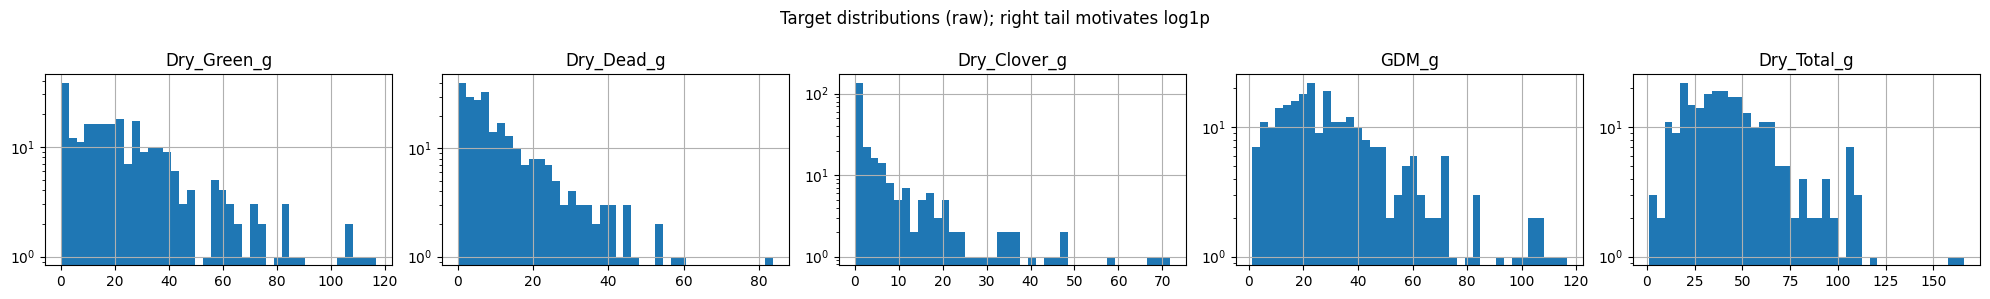

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3))
for ax, t in zip(axes, TARGETS):
    train_df[t].dropna().hist(bins=40, ax=ax)
    ax.set_title(t); ax.set_yscale("log")
plt.suptitle("Target distributions (raw); right tail motivates log1p")
plt.tight_layout(); plt.show()


## 6. PyTorch Dataset and DataLoader

Each item yields `(image_tensor, tabular_tensor, target_tensor, image_path)`.
The `_load_image` helper has a fallback that tries common subdir layouts in
case `image_path` doesn't resolve directly under `DATA_DIR`. Additionally, we normalize by the same means and standard deviations seen in IMAGENET, the dataset used for the ResNet18 model.


In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


In [9]:
class PastureDataset(Dataset):
    def __init__(self, df, data_dir, transform=None, has_targets=True):
        self.df = df.reset_index(drop=True)
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.has_targets = has_targets

    def __len__(self):
        return len(self.df)

    def _load_image(self, rel_path):
        path = self.data_dir / rel_path
        if not path.exists():
            basename = Path(rel_path).name
            for sub in ("images", "train", "test", ""):
                alt = self.data_dir / sub / basename
                if alt.exists():
                    return Image.open(alt).convert("RGB")
            raise FileNotFoundError(f"image not found: {rel_path}")
        return Image.open(path).convert("RGB")

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load_image(row["image_path"])
        if self.transform: img = self.transform(img)
        tab = torch.tensor([float(row[c]) for c in TABULAR_FEATURES], dtype=torch.float32)
        if self.has_targets:
            y = torch.tensor([float(row[t]) if pd.notna(row[t]) else 0.0
                              for t in TARGETS], dtype=torch.float32)
        else:
            y = torch.zeros(len(TARGETS), dtype=torch.float32)
        return img, tab, y, str(row["image_path"])

# Quick sanity check
_ds = PastureDataset(train_df, DATA_DIR, transform=val_transform)
img, tab, y, p = _ds[0]
print("image:", img.shape, "tab:", tab.shape, "targets:", y.shape, "path:", p)


image: torch.Size([3, 224, 224]) tab: torch.Size([2]) targets: torch.Size([5]) path: train/ID1573329652.jpg


Generative AI was consulted and used to make the above class robust to errors that might arise.

## 7. Visualize a few training images

This is primarily to ensure that the class defined above is behaving as we expect it to, with image retrieval working as intended, that the transform is producing valid image tensors, and that the target vector is being returned correctly.

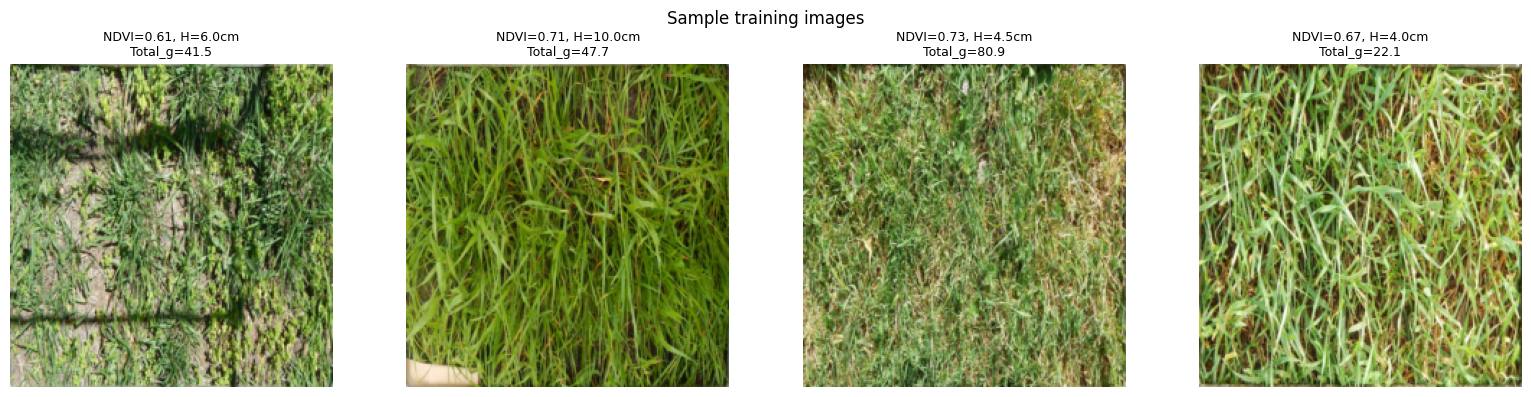

In [10]:
_ds = PastureDataset(train_df, DATA_DIR, transform=val_transform)
mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
std  = torch.tensor(IMAGENET_STD).view(3,1,1)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, idx in zip(axes, range(4)):
    img, tab, y, _ = _ds[idx]
    disp = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(disp)
    ax.set_title(f"NDVI={tab[0]:.2f}, H={tab[1]:.1f}cm\nTotal_g={y[4]:.1f}", fontsize=9)
    ax.axis("off")
plt.suptitle("Sample training images")
plt.tight_layout(); plt.show()

Note: Generative AI was used for syntax purposes on the above plots.

## 8. Evaluation metric — globally weighted R²

This is the code segment that we used to transform the weighted R-squared described in the competition for our own evaluation metrics, which we then call in our training loops. We included some checks to make sure that this was behaving as expected for at least two simple cases to ensure what we believed to be a reasonable implementation was acting as desired.


In [11]:
def weighted_r2(y_true_mat, y_pred_mat):
    """Globally weighted R². Inputs are (N_images, 5) matrices in native gram scale."""
    y_true = np.asarray(y_true_mat, dtype=np.float64)
    y_pred = np.asarray(y_pred_mat, dtype=np.float64)
    N = y_true.shape[0]
    w_vec = np.array([TARGET_WEIGHTS[t] for t in TARGETS], dtype=np.float64)
    w = np.tile(w_vec, N)
    yt = y_true.reshape(-1)
    yp = y_pred.reshape(-1)
    wsum = w.sum()
    ybar = (w * yt).sum() / wsum
    ss_res = (w * (yt - yp) ** 2).sum()
    ss_tot = (w * (yt - ybar) ** 2).sum()
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

def per_target_metrics(y_true, y_pred):
    rows = []
    for k, name in enumerate(TARGETS):
        yt = y_true[:, k]; yp = y_pred[:, k]
        ss_res = ((yt - yp) ** 2).sum()
        ss_tot = ((yt - yt.mean()) ** 2).sum()
        r2  = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")
        mae = np.abs(yt - yp).mean()
        rmse = np.sqrt(((yt - yp) ** 2).mean())
        rows.append({"target": name, "weight": TARGET_WEIGHTS[name],
                     "R2": r2, "MAE": mae, "RMSE": rmse})
    df = pd.DataFrame(rows)
    df.loc[len(df)] = {"target": "OVERALL_weighted_R2", "weight": np.nan,
                       "R2": weighted_r2(y_true, y_pred), "MAE": np.nan, "RMSE": np.nan}
    return df

# Unit tests
_y = np.random.RandomState(0).rand(20, 5) * 100

print(f"perfect preds R²: {weighted_r2(_y, _y):.4f}  (expect 1.0)")

w_vec = np.array([TARGET_WEIGHTS[t] for t in TARGETS], dtype=np.float64)
w = np.tile(w_vec, _y.shape[0])
yt = _y.reshape(-1)

global_weighted_mean = (w * yt).sum() / w.sum()
_y_global_mean = np.full_like(_y, global_weighted_mean)

print(f"global weighted mean predictor R²: {weighted_r2(_y, _y_global_mean):.4f}")


perfect preds R²: 1.0000  (expect 1.0)
global weighted mean predictor R²: 0.0000


## 9. Shared training loop

We design a reusable training loop that applies to both the CNN and the fine-tuning case below, using the homework as a model.


In [12]:
@torch.no_grad()
def evaluate(model, loader):
    """Return (weighted_r2, y_true, y_pred) on the loader."""
    model.eval()
    yts, yps = [], []
    for img, tab, y, _ in loader:
        img = img.to(device); tab = tab.to(device)
        pred_log = model(img, tab).cpu().numpy()
        pred_log = np.clip(pred_log, -1, 7)          # expm1(7) ≈ 1096, safely above any real target
        yp = np.clip(np.expm1(pred_log), 0, None)
        yts.append(y.numpy()); yps.append(yp)
    yt = np.concatenate(yts); yp = np.concatenate(yps)
    return weighted_r2(yt, yp), yt, yp


def train_model(model, train_loader, val_loader,
                lr=1e-3, weight_decay=0.0, epochs=15, patience=3,
                use_amp=False, grad_clip=None, log_every=1):
    """Generic train loop. Targets are log1p-transformed inside the loop."""
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    train_loss, val_score = [], []
    best_val = -float("inf"); best_state = None; no_improve = 0
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        running, n = 0.0, 0
        for img, tab, y, _ in train_loader:
            img = img.to(device, non_blocking=True)
            tab = tab.to(device, non_blocking=True)
            y   = y.to(device, non_blocking=True)
            y_log = torch.log1p(torch.clamp(y, min=0.0))

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                pred = model(img, tab)
                loss = criterion(pred, y_log)
            scaler.scale(loss).backward()
            if grad_clip:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer); scaler.update()

            running += loss.item() * y.size(0); n += y.size(0)

        train_loss.append(running / n)
        score, _, _ = evaluate(model, val_loader)
        val_score.append(score)
        if epoch % log_every == 0:
            print(f"  epoch {epoch:02d}/{epochs} | train_mse_log={train_loss[-1]:.4f} | val_wR²={score:.4f}")

        if score > best_val:
            best_val = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  early stopping at epoch {epoch} (no improvement for {patience} epochs)")
                break

    print(f"  done in {time.time() - t0:.1f}s | best val weighted R² = {best_val:.4f}")
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, train_loss, val_score


def plot_curves(train_loss, val_score, title):
    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(train_loss, color="tab:blue", label="train MSE (log)")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("train MSE", color="tab:blue")
    ax2 = ax1.twinx()
    ax2.plot(val_score, color="tab:orange", label="val weighted R²")
    ax2.set_ylabel("val weighted R²", color="tab:orange")
    plt.title(title); fig.tight_layout(); plt.show()


The above code block was a created in the following manner: taking the homework assignment on CNNs and Transfer Learning as a framework, I creaed a potential training loop, then utilized generative AI to convert this into one that fully type-checked with my input data and given evaluation metrics.

## 10. Build DataLoaders for each track

In [13]:
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(PastureDataset(train_df, DATA_DIR, train_transform),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(PastureDataset(val_df,   DATA_DIR, val_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(PastureDataset(test_df,  DATA_DIR, val_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print("loaders ready")


loaders ready


## 11. Sanity-floor baseline: predict the per-target train mean

Naive heuristic, just predicting the mean of each given output feature in the train set for the test set.


In [14]:
train_means = train_df[TARGETS].mean().values
y_test = test_df[TARGETS].values
baseline_pred = np.tile(train_means, (len(test_df), 1))
print(f"Predict-train-mean baseline weighted R² on local test: {weighted_r2(y_test, baseline_pred):.4f}")


Predict-train-mean baseline weighted R² on local test: 0.2122


We observe better-than-the-most-naive baseline of predicting mean across the entire dataset since each output feature tends to be on completely different scales from each other, so we are utilizing more information than the R-squared of 0 method of averaging across everything that the competition baseline uses.

# Custom CNN from Scratch

The following CNN uses four convolutional blocks. We note that we divert from the course convention of using BatchNorm due to the relatively small size of our dataset and batches, instead opting to use the typical choice to solve this problem with the GroupNorm. In particular, since these images vary a lot in color and features, we note that the batch size is not large enough for meaningful statistical convergence across images, and thus found it was more useful to normalize within a given image for better convergence. Then, we fuse these blocks with the tabular features and use an MLP head to map to our output space (the 5 features the Kaggle competition cares about), but do so in log1p space to handle outliers.


In [15]:
torch.manual_seed(2025)

class CustomCNN(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        # GroupNorm(num_groups, num_channels) — no running statistics,
        # so no train/eval mismatch on small datasets.
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  nn.GroupNorm(8, 32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.GroupNorm(8, 64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.GroupNorm(8, 128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.GroupNorm(8, 256), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256 + 2, 128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 5),
        )

    def forward(self, image, tab):
        feat = self.features(image)
        return self.head(torch.cat([feat, tab], dim=1))

cnn = CustomCNN()
print(f"CustomCNN parameters: {sum(p.numel() for p in cnn.parameters()):,}")


CustomCNN parameters: 423,173


Similar to our courses CNN we developed in HW 4.

## Train the custom CNN

Training from scratch:
  epoch 01/25 | train_mse_log=3.8872 | val_wR²=-0.3075
  epoch 02/25 | train_mse_log=1.4187 | val_wR²=-0.3385
  epoch 03/25 | train_mse_log=1.2738 | val_wR²=0.0002
  epoch 04/25 | train_mse_log=1.1576 | val_wR²=0.1471
  epoch 05/25 | train_mse_log=1.2472 | val_wR²=0.2304
  epoch 06/25 | train_mse_log=1.0898 | val_wR²=0.3237
  epoch 07/25 | train_mse_log=1.1344 | val_wR²=0.2763
  epoch 08/25 | train_mse_log=1.0617 | val_wR²=0.3422
  epoch 09/25 | train_mse_log=1.0302 | val_wR²=0.4334
  epoch 10/25 | train_mse_log=1.0297 | val_wR²=0.4284
  epoch 11/25 | train_mse_log=1.0139 | val_wR²=0.4325
  epoch 12/25 | train_mse_log=1.0186 | val_wR²=0.2803
  epoch 13/25 | train_mse_log=0.9375 | val_wR²=0.4461
  epoch 14/25 | train_mse_log=0.9603 | val_wR²=0.3663
  epoch 15/25 | train_mse_log=1.0163 | val_wR²=0.4569
  epoch 16/25 | train_mse_log=0.9645 | val_wR²=0.3608
  epoch 17/25 | train_mse_log=0.9814 | val_wR²=0.4371
  epoch 18/25 | train_mse_log=0.9822 | val_wR²=0.4213
  e

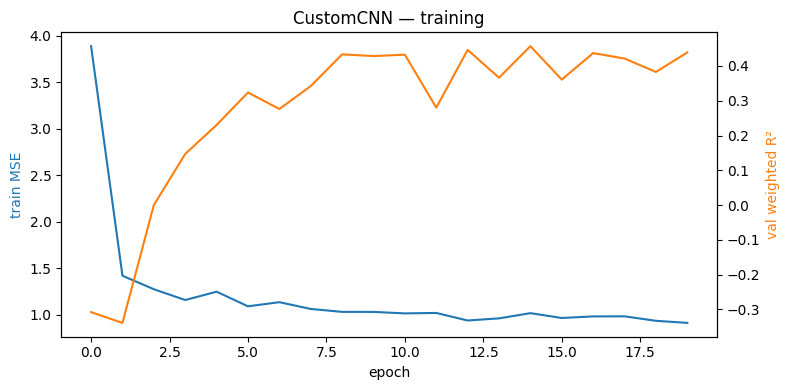

In [16]:
torch.manual_seed(2025)
cnn = CustomCNN(dropout=0.3)

print("Training from scratch:")
cnn, train_loss_A, val_score_A = train_model(
    cnn, train_loader, val_loader,
    lr=1e-3, weight_decay=1e-4,
    epochs=25, patience=5,
    use_amp=False,
)
plot_curves(train_loss_A, val_score_A, "CustomCNN — training")


When using BatchNorm, we observed that training loss in MSE would decrease consistently while the validation R-squared would oscilate wildly, leading to the implementation decision to instead use GroupNorm for training stability.

## Evaluating on local test set

In [17]:
score_A, yt_A, yp_A = evaluate(cnn, test_loader)
print(f"CustomCNN local test weighted R²: {score_A:.4f}")
print()
print(per_target_metrics(yt_A, yp_A).to_string(index=False))


CustomCNN local test weighted R²: 0.4590

             target  weight        R2       MAE      RMSE
        Dry_Green_g     0.1  0.471112 11.796704 17.744982
         Dry_Dead_g     0.1  0.084620  7.240253 10.123145
       Dry_Clover_g     0.1 -0.034702  5.625182 10.508498
              GDM_g     0.2  0.438636 15.185854 18.951897
        Dry_Total_g     0.5  0.253758 19.985363 24.463009
OVERALL_weighted_R2     NaN  0.458950       NaN       NaN


/tmp/ipykernel_1148/28260283.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df.loc[len(df)] = {"target": "OVERALL_weighted_R2", "weight": np.nan,


Given the size of the dataset (order of hundreds of images), it is not unreasonable to think that transfer learning from a pretrained net could provide better results, motivating the following exploration.

# Transfer learning with a pretrained ResNet18

This model uses a similar idea to the fine-tuning "transfer learning" from homework 4. We load in ResNet18 with ImageNet weights, strip the classification head, and replace it with a regression head that fuses image features with tabular ones and then fine-tune the model as did in homework 4.


In [18]:
torch.manual_seed(2025)

class PretrainedResNet18(nn.Module):
    """ResNet18 with classifier replaced by a regression head; tabular
    features concatenated to the pooled image features before the head."""
    def __init__(self, dropout=0.3):
        super().__init__()
        backbone = models.resnet18(weights="DEFAULT")
        in_feats = backbone.fc.in_features                # 512 for resnet18
        backbone.fc = nn.Identity()                        # strip classifier
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_feats + 2, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 5),
        )

    def forward(self, image, tab):
        feat = self.backbone(image)
        return self.head(torch.cat([feat, tab], dim=1))

resnet = PretrainedResNet18()
print(f"ResNet18 (pretrained) parameters: {sum(p.numel() for p in resnet.parameters()):,}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 277MB/s]

ResNet18 (pretrained) parameters: 11,243,077


Above code generated using homework code formatting, personal edits, and generative AI to verify and suggest edits to failing portions.

## Fine-tune the pretrained ResNet18

Fine-tuning pretrained ResNet18:
  epoch 01/25 | train_mse_log=7.9953 | val_wR²=-1.1754
  epoch 02/25 | train_mse_log=5.9476 | val_wR²=-1.1053
  epoch 03/25 | train_mse_log=3.9696 | val_wR²=-0.9323
  epoch 04/25 | train_mse_log=2.2521 | val_wR²=-0.6196
  epoch 05/25 | train_mse_log=1.2359 | val_wR²=-0.2483
  epoch 06/25 | train_mse_log=0.9899 | val_wR²=0.1398
  epoch 07/25 | train_mse_log=0.9539 | val_wR²=0.0951
  epoch 08/25 | train_mse_log=0.8278 | val_wR²=0.0322
  epoch 09/25 | train_mse_log=0.8132 | val_wR²=0.1488
  epoch 10/25 | train_mse_log=0.7690 | val_wR²=0.3184
  epoch 11/25 | train_mse_log=0.6948 | val_wR²=0.2134
  epoch 12/25 | train_mse_log=0.6763 | val_wR²=0.3196
  epoch 13/25 | train_mse_log=0.6368 | val_wR²=0.2031
  epoch 14/25 | train_mse_log=0.6344 | val_wR²=0.2839
  epoch 15/25 | train_mse_log=0.6071 | val_wR²=0.4555
  epoch 16/25 | train_mse_log=0.6705 | val_wR²=0.4295
  epoch 17/25 | train_mse_log=0.6277 | val_wR²=0.3801
  epoch 18/25 | train_mse_log=0.5283 | val_w

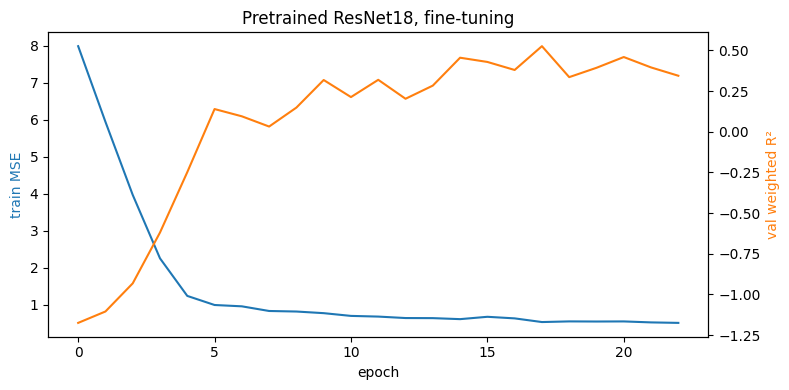

In [19]:
torch.manual_seed(2025)
resnet = PretrainedResNet18(dropout=0.3)

print("Fine-tuning pretrained ResNet18:")
resnet, train_loss_B, val_score_B = train_model(
    resnet, train_loader, val_loader,
    lr=1e-4, weight_decay=1e-4,
    epochs=25, patience=5,
    use_amp=(device.type == "cuda"),
    grad_clip=1.0,
)
plot_curves(train_loss_B, val_score_B, "Pretrained ResNet18, fine-tuning")


## Evaluate on local test set

In [20]:
score_B, yt_B, yp_B = evaluate(resnet, test_loader)
print(f"Pretrained ResNet18 (fine-tuned) local test weighted R²: {score_B:.4f}")
print()
print(per_target_metrics(yt_B, yp_B).to_string(index=False))


Pretrained ResNet18 (fine-tuned) local test weighted R²: 0.5653

             target  weight       R2       MAE      RMSE
        Dry_Green_g     0.1 0.473989 10.846419 17.696667
         Dry_Dead_g     0.1 0.254810  6.079715  9.133730
       Dry_Clover_g     0.1 0.137987  4.467681  9.591576
              GDM_g     0.2 0.609778 11.184932 15.801068
        Dry_Total_g     0.5 0.397223 16.858511 21.986109
OVERALL_weighted_R2     NaN 0.565345       NaN       NaN


/tmp/ipykernel_1148/28260283.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df.loc[len(df)] = {"target": "OVERALL_weighted_R2", "weight": np.nan,


## 12. Side-by-side comparison

                           model  test_weighted_R2
     Predict-train-mean baseline          0.212215
CustomCNN (trained from scratch)          0.458950
Pretrained ResNet18 (fine-tuned)          0.565345


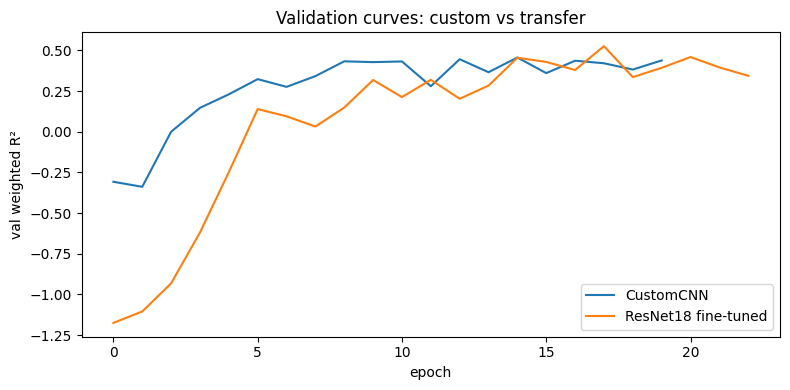

In [21]:
summary = pd.DataFrame([
    {"model": "Predict-train-mean baseline", "test_weighted_R2": weighted_r2(y_test, baseline_pred)},
    {"model": "CustomCNN (trained from scratch)", "test_weighted_R2": score_A},
    {"model": "Pretrained ResNet18 (fine-tuned)", "test_weighted_R2": score_B},
])
print(summary.to_string(index=False))

# Compare training curves on one chart
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(val_score_A, label="CustomCNN", color="tab:blue")
ax.plot(val_score_B, label="ResNet18 fine-tuned", color="tab:orange")
ax.set_xlabel("epoch"); ax.set_ylabel("val weighted R²")
ax.set_title("Validation curves: custom vs transfer")
ax.legend(); fig.tight_layout(); plt.show()


In [22]:
def test_rmse(y_true, y_pred):
    rows = []
    for k, t in enumerate(TARGETS):
        rmse = np.sqrt(((y_true[:, k] - y_pred[:, k]) ** 2).mean())
        rows.append({"target": t, "RMSE": rmse})
    overall = np.sqrt(((y_true - y_pred) ** 2).mean())
    rows.append({"target": "OVERALL", "RMSE": overall})
    return pd.DataFrame(rows)

print("=== CustomCNN ===")
print(test_rmse(yt_A, yp_A).to_string(index=False))
print(f"\n=== ResNet18 (fine-tuned) ===")
print(test_rmse(yt_B, yp_B).to_string(index=False))

=== CustomCNN ===
      target      RMSE
 Dry_Green_g 17.744982
  Dry_Dead_g 10.123145
Dry_Clover_g 10.508498
       GDM_g 18.951897
 Dry_Total_g 24.463009
     OVERALL 17.236032

=== ResNet18 (fine-tuned) ===
      target      RMSE
 Dry_Green_g 17.696667
  Dry_Dead_g  9.133730
Dry_Clover_g  9.591576
       GDM_g 15.801068
 Dry_Total_g 21.986109
     OVERALL 15.631110


The above shows that our fine-tuned model performs better across every output value (and as a corollary, overall), and thus it seems to be the better model for this given task.

Also note: Generative AI was used for syntax for the plot and test_rmse function.

## 13. Error analysis by type on the ResNet and the Custom CNN

Per-target residual histograms for the ResNet and the CustomCNN


Showing error analysis for: ResNet18


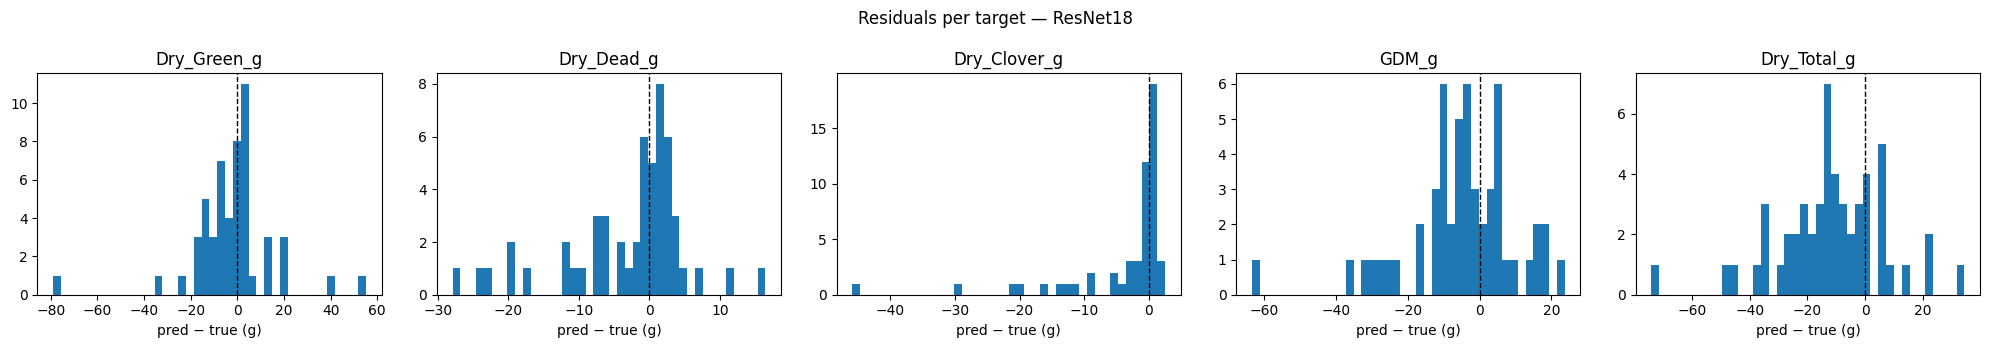

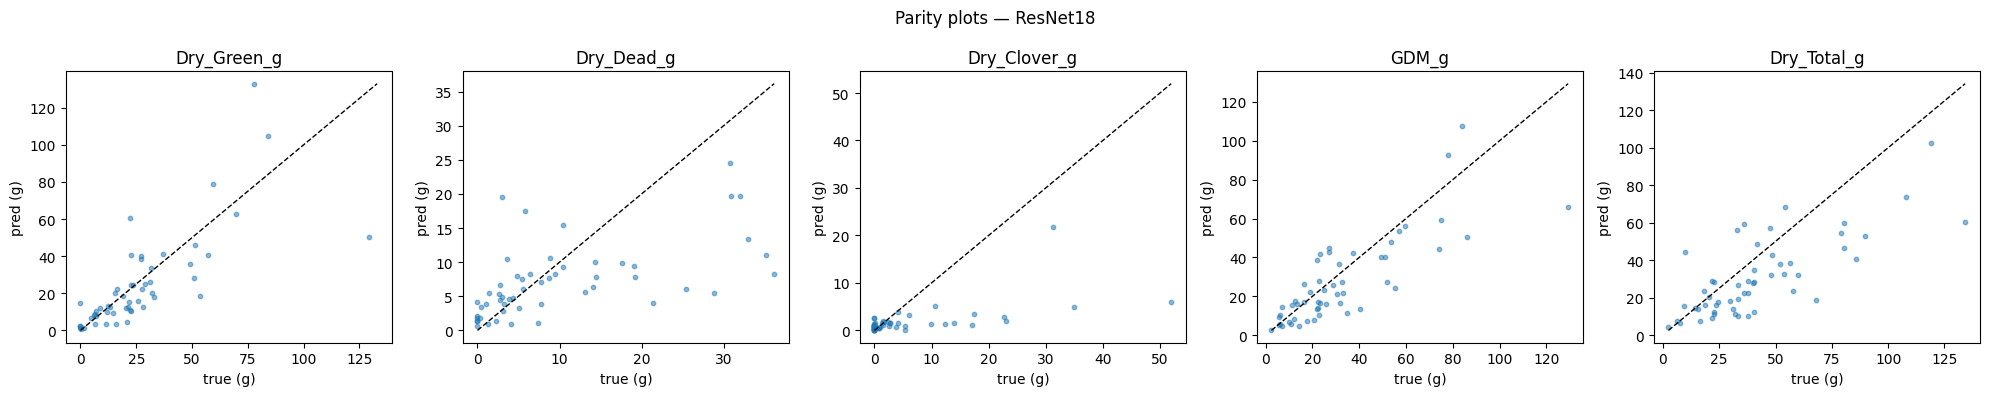

In [23]:
better = "ResNet18"
yt_best, yp_best = (yt_B, yp_B) if score_B >= score_A else (yt_A, yp_A)
print(f"Showing error analysis for: {better}")

# Residuals
resid = yp_best - yt_best
fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
for ax, t, k in zip(axes, TARGETS, range(5)):
    ax.hist(resid[:, k], bins=40)
    ax.axvline(0, color="k", linestyle="--", linewidth=1)
    ax.set_title(t); ax.set_xlabel("pred − true (g)")
plt.suptitle(f"Residuals per target — {better}")
plt.tight_layout(); plt.show()

# Parity plots
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, t, k in zip(axes, TARGETS, range(5)):
    ax.scatter(yt_best[:, k], yp_best[:, k], s=10, alpha=0.5)
    lo = min(yt_best[:, k].min(), yp_best[:, k].min())
    hi = max(yt_best[:, k].max(), yp_best[:, k].max())
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1)
    ax.set_title(t); ax.set_xlabel("true (g)"); ax.set_ylabel("pred (g)")
plt.suptitle(f"Parity plots — {better}")
plt.tight_layout(); plt.show()


Showing error analysis for: CustomCNN


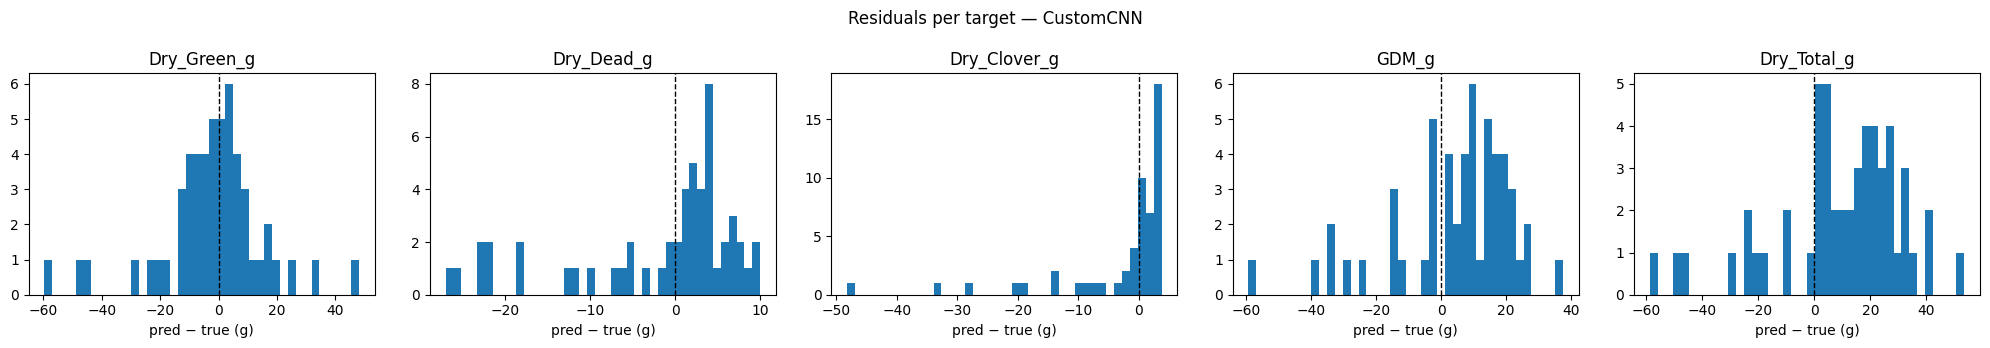

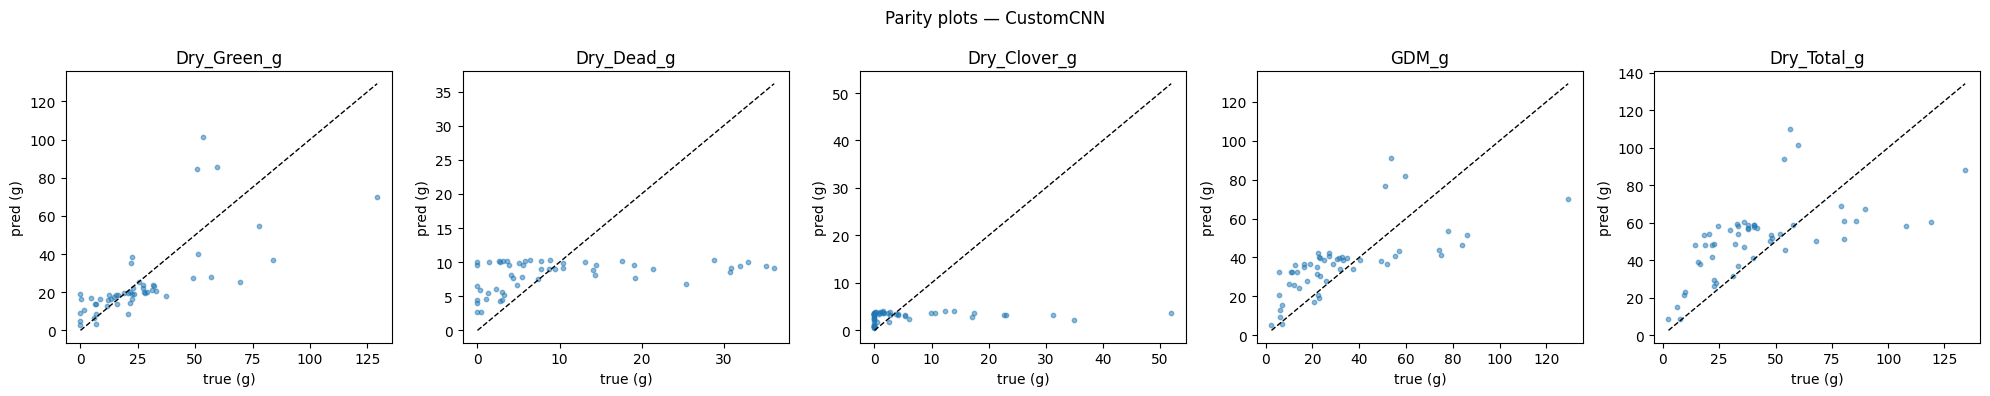

In [24]:
worse = "CustomCNN"
yt_worse, yp_worse = (yt_A, yp_A)
print(f"Showing error analysis for: {worse}")

# Residuals
resid = yp_worse - yt_worse
fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
for ax, t, k in zip(axes, TARGETS, range(5)):
    ax.hist(resid[:, k], bins=40)
    ax.axvline(0, color="k", linestyle="--", linewidth=1)
    ax.set_title(t); ax.set_xlabel("pred − true (g)")
plt.suptitle(f"Residuals per target — {worse}")
plt.tight_layout(); plt.show()

# Parity plots
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, t, k in zip(axes, TARGETS, range(5)):
    ax.scatter(yt_worse[:, k], yp_worse[:, k], s=10, alpha=0.5)
    lo = min(yt_worse[:, k].min(), yp_worse[:, k].min())
    hi = max(yt_worse[:, k].max(), yp_worse[:, k].max())
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1)
    ax.set_title(t); ax.set_xlabel("true (g)"); ax.set_ylabel("pred (g)")
plt.suptitle(f"Parity plots — {worse}")
plt.tight_layout(); plt.show()

Note: Generative AI was used for plot syntax.

In the above, we can qualitatively observe that across all output features, our fine-tuned model appears to be better calibrated and more correlated with our true target features than the CustomCNN model.

For future work, one thing to note is how poorly both models perform on the Dry_Clover_g portion, tending to vastly underpredict. This may be an issue with it contributing relatively less than Dry_Green_g, GDM_g, and Dry_Total_g to the training metrics, and thus could be a useful path for the future to alleviate for a better model.

## 14. Saving the ResNet and the Custom CNN results

Saving results to a google drive folder for future model comparison.


In [25]:
import pickle
from pathlib import Path

RESULTS_DIR = Path("/content/drive/MyDrive/biomass_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

cnn_results = {
    "models": {
        "Custom CNN": {
            "test_weighted_r2": score_A,
            "test_preds": yp_A,
            "test_true": yt_A,
            "per_target": per_target_metrics(yt_A, yp_A),
            "train_loss": train_loss_A,
            "val_score": val_score_A,
        },
        "ResNet18 fine-tuned": {
            "test_weighted_r2": score_B,
            "test_preds": yp_B,
            "test_true": yt_B,
            "per_target": per_target_metrics(yt_B, yp_B),
            "train_loss": train_loss_B,
            "val_score": val_score_B,
        },
    }
}

with open(RESULTS_DIR / "cnn_results.pkl", "wb") as f:
    pickle.dump(cnn_results, f)
print(f"Saved CNN results to {RESULTS_DIR / 'cnn_results.pkl'}")

/tmp/ipykernel_1148/28260283.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df.loc[len(df)] = {"target": "OVERALL_weighted_R2", "weight": np.nan,
/tmp/ipykernel_1148/28260283.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df.loc[len(df)] = {"target": "OVERALL_weighted_R2", "weight": np.nan,


Saved CNN results to /content/drive/MyDrive/biomass_results/cnn_results.pkl
